In [22]:
!pip install transformers datasets torch pandas matplotlib evaluate

## 2. 导入库

In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
import re
from tqdm.auto import tqdm

from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from datasets import load_dataset
import evaluate


In [24]:

MODEL_NAME = "deepset/roberta-base-squad2"  # 推荐：准确率高，支持无法回答
# MODEL_NAME = "distilbert-base-uncased-distilled-squad"  # 备选：更快
# MODEL_NAME = "bert-large-uncased-whole-word-masking-finetuned-squad"  # 备选：最准确但慢

# 测试样本数（SQuAD 验证集）
EVAL_SAMPLE_SIZE = None 

PHASE1_JSON = "librispeech_local_1500.json"  

#output
OUTPUT_RESULTS = "phase3b_qa_results.json"
OUTPUT_EVALUATION = "phase3b_evaluation.json"


In [25]:

# 创建 QA pipeline
qa_pipeline = pipeline(
    "question-answering",
    model=MODEL_NAME,
    device=-1  
)

squad = load_dataset("squad_v2")
val_data = squad['validation']

if EVAL_SAMPLE_SIZE:
    val_sample = val_data.select(range(min(EVAL_SAMPLE_SIZE, len(val_data))))
else:
    val_sample = val_data



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 731.58it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:

predictions = []
references = []

for i, example in enumerate(tqdm(val_sample, desc="评估中")):
    # 获取问题和上下文
    question = example['question']
    context = example['context']
    
    # 预测答案
    try:
        result = qa_pipeline(
            question=question,
            context=context
        )
        
        predicted_answer = result['answer']
        confidence = result['score']
    except Exception as e:
        predicted_answer = ""
        confidence = 0.0
    
    # 获取真实答案
    if example['answers']['text']:
        true_answers = example['answers']['text']
    else:
        true_answers = []
    
    # 保存
    predictions.append({
        'id': example['id'],
        'question': question,
        'predicted_answer': predicted_answer,
        'true_answers': true_answers,
        'confidence': confidence
    })
    
    # 用于计算指标
    references.append({
        'id': example['id'],
        'answers': example['answers']
    })

print(f"\n✓ 评估完成: {len(predictions)} 个样本")

评估中: 100%|██████████| 11873/11873 [30:46<00:00,  6.43it/s] 


✓ 评估完成: 11873 个样本


In [34]:

def normalize_answer(s):
    """标准化答案（小写、去除标点、多余空格）"""
    import string
    s = s.lower()
    s = ''.join(ch for ch in s if ch not in string.punctuation)
    s = ' '.join(s.split())
    return s

def compute_exact_match(prediction, ground_truths):
    """计算精确匹配 (EM)"""
    prediction = normalize_answer(prediction)
    for truth in ground_truths:
        if normalize_answer(truth) == prediction:
            return 1
    return 0

def compute_f1(prediction, ground_truths):
    """计算 F1 分数"""
    prediction_tokens = normalize_answer(prediction).split()
    
    f1_scores = []
    for truth in ground_truths:
        truth_tokens = normalize_answer(truth).split()
        
        common = Counter(prediction_tokens) & Counter(truth_tokens)
        num_same = sum(common.values())
        
        if num_same == 0:
            f1_scores.append(0)
        else:
            precision = num_same / len(prediction_tokens) if prediction_tokens else 0
            recall = num_same / len(truth_tokens) if truth_tokens else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            f1_scores.append(f1)
    
    return max(f1_scores) if f1_scores else 0

# 计算指标
em_scores = []
f1_scores = []

for pred in predictions:
    predicted = pred['predicted_answer']
    ground_truths = pred['true_answers'] if pred['true_answers'] else [""]
    
    em = compute_exact_match(predicted, ground_truths)
    f1 = compute_f1(predicted, ground_truths)
    
    em_scores.append(em)
    f1_scores.append(f1)

# 计算平均值
avg_em = np.mean(em_scores) * 100
avg_f1 = np.mean(f1_scores) * 100

print(f"样本数: {len(predictions)}")
print(f"\nExact Match (EM): {avg_em:.2f}%")
print(f"F1 Score:         {avg_f1:.2f}%")


样本数: 11873

Exact Match (EM): 41.23%
F1 Score:         45.47%


In [35]:

# 找出预测错误的例子
errors = []
correct = []

for i, (pred, em) in enumerate(zip(predictions, em_scores)):
    if em == 0:
        errors.append((i, pred))
    else:
        correct.append((i, pred))

print(f"\n正确预测: {len(correct)} ({len(correct)/len(predictions)*100:.1f}%)")
print(f"错误预测: {len(errors)} ({len(errors)/len(predictions)*100:.1f}%)")



正确预测: 4895 (41.2%)
错误预测: 6978 (58.8%)


分析预测置信度...

置信度统计:
  平均: 0.3215
  中位数: 0.1752
  最小: 0.0000
  最大: 1.9333


C:\Users\luka\AppData\Local\Temp\ipykernel_19676\38327273.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([correct_conf, error_conf], labels=['Correct', 'Incorrect'])


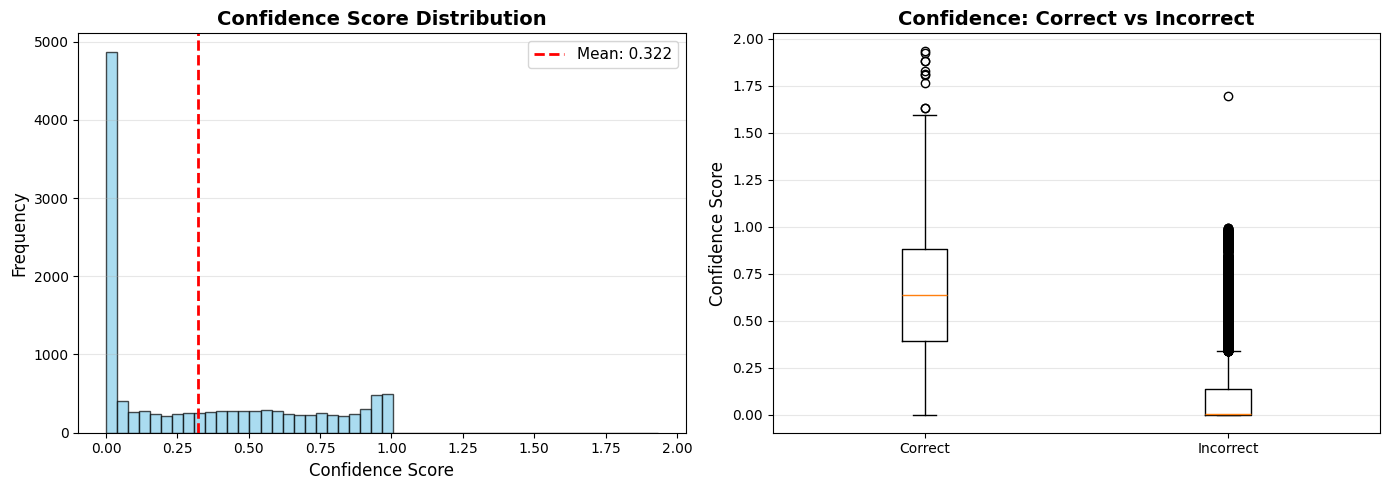


✓ 图表已保存: qa_confidence_analysis.png

观察:
  - 正确预测平均置信度: 0.6078
  - 错误预测平均置信度: 0.1206
  - 差异: 0.4872


In [36]:
print("分析预测置信度...")

confidences = [pred['confidence'] for pred in predictions]

print(f"\n置信度统计:")
print(f"  平均: {np.mean(confidences):.4f}")
print(f"  中位数: {np.median(confidences):.4f}")
print(f"  最小: {np.min(confidences):.4f}")
print(f"  最大: {np.max(confidences):.4f}")

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 置信度分布
ax1.hist(confidences, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
ax1.axvline(np.mean(confidences), color='red', linestyle='--', 
            label=f'Mean: {np.mean(confidences):.3f}', linewidth=2)
ax1.set_xlabel('Confidence Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 正确 vs 错误的置信度
correct_conf = [predictions[i]['confidence'] for i, em in enumerate(em_scores) if em == 1]
error_conf = [predictions[i]['confidence'] for i, em in enumerate(em_scores) if em == 0]

ax2.boxplot([correct_conf, error_conf], labels=['Correct', 'Incorrect'])
ax2.set_ylabel('Confidence Score', fontsize=12)
ax2.set_title('Confidence: Correct vs Incorrect', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('qa_confidence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ 图表已保存: qa_confidence_analysis.png")

print(f"\n观察:")
if correct_conf and error_conf:
    print(f"  - 正确预测平均置信度: {np.mean(correct_conf):.4f}")
    print(f"  - 错误预测平均置信度: {np.mean(error_conf):.4f}")
    print(f"  - 差异: {np.mean(correct_conf) - np.mean(error_conf):.4f}")

In [40]:

# 加载 Phase 1 转录结果
with open(PHASE1_JSON, 'r', encoding='utf-8') as f:
    phase1_data = json.load(f)
    
transcriptions = [r['transcription'] for r in phase1_data['results'] if r['success']]
    
print(f"✓ 加载了 {len(transcriptions)} 条转录文本")   
sample_questions = [
        "What is this text about?",
        "Who is mentioned in this text?",
        "When did this happen?",
        "Where does this take place?",
        "What was the main event?"
    ]
    
print(f"\n在前5条转录上测试 QA 系统...")
print("="*80)
    
qa_examples = []
    
for i, text in enumerate(transcriptions[:5]):
        print(f"\n转录 {i+1}:")
        print(f"文本: {text[:200]}...")
        print(f"\n问答:")
        
        for question in sample_questions:
            try:
                result = qa_pipeline(
                    question=question,
                    context=text
                )
                
                if result['score'] > 0.1:  # 只显示高置信度的答案
                    print(f"  Q: {question}")
                    print(f"  A: {result['answer']} (置信度: {result['score']:.3f})")
                    
                    qa_examples.append({
                        'text_index': i,
                        'text_preview': text[:100],
                        'question': question,
                        'answer': result['answer'],
                        'confidence': result['score']
                    })
            except:
                pass
        
        print("-" * 80)
    
    
    

✓ 加载了 1500 条转录文本

在前5条转录上测试 QA 系统...

转录 1:
文本: He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour fat and sauce....

问答:
  Q: What was the main event?
  A: stew for dinner (置信度: 0.416)
--------------------------------------------------------------------------------

转录 2:
文本: Stuff it into you, his belly counseled him....

问答:
--------------------------------------------------------------------------------

转录 3:
文本: After early nightfall, the yellow lamps would light up here and there, the squalid quarter of the brothels....

问答:
  Q: When did this happen?
  A: After early nightfall (置信度: 0.382)
  Q: Where does this take place?
  A: the squalid quarter of the brothels (置信度: 0.295)
--------------------------------------------------------------------------------

转录 4:
文本: Hello, Bertie. Any good in your mind?...

问答:
---------------------------------------------------------------------------

In [41]:
def ask_question(context, question, show_context=True):
    """
    交互式问答函数
    
    Args:
        context: 上下文文本
        question: 问题
        show_context: 是否显示上下文
    
    Returns:
        dict: 包含答案和置信度
    """
    if show_context:
        print("\n" + "="*80)
        print("上下文:")
        print("="*80)
        print(context[:300] + "..." if len(context) > 300 else context)
    
    print("\n" + "="*80)
    print(f"问题: {question}")
    print("="*80)
    
    result = qa_pipeline(
        question=question,
        context=context
    )
    
    print(f"\n答案: {result['answer']}")
    print(f"置信度: {result['score']:.4f}")
    
    if result['score'] < 0.1:
        print("⚠️  低置信度，可能无法回答此问题")
    elif result['score'] < 0.5:
        print("⚠️  中等置信度，答案可能不完全准确")
    else:
        print("✓ 高置信度")
    
    return result

print("✓ 交互式 QA 函数已定义")
print("\n使用方法:")
print("  result = ask_question(context='您的文本', question='您的问题')")

# 示例使用
if transcriptions:
    print("\n示例使用:")
    ask_question(
        context=transcriptions[0],
        question="What is the main topic?"
    )

✓ 交互式 QA 函数已定义

使用方法:
  result = ask_question(context='您的文本', question='您的问题')

示例使用:

上下文:
He hoped there would be stew for dinner, turnips and carrots and bruised potatoes and fat mutton pieces to be ladled out in thick, peppered flour fat and sauce.

问题: What is the main topic?

答案: stew for dinner
置信度: 0.0315
⚠️  低置信度，可能无法回答此问题


In [44]:
print("保存评估结果...")

# 保存详细预测结果
results_output = {
    'metadata': {
        'model': MODEL_NAME,
        'eval_samples': len(predictions),
        'metrics': {
            'exact_match': float(avg_em),
            'f1_score': float(avg_f1)
        }
    },
    'predictions': predictions 
}

with open(OUTPUT_RESULTS, 'w', encoding='utf-8') as f:
    json.dump(results_output, f, ensure_ascii=False, indent=2)

print(f"✓ 结果已保存: {OUTPUT_RESULTS}")

# 保存评估报告
evaluation_output = {
    'model': MODEL_NAME,
    'dataset': 'SQuAD v2',
    'eval_samples': len(predictions),
    'metrics': {
        'exact_match': float(avg_em),
        'f1_score': float(avg_f1),
        'avg_confidence': float(np.mean(confidences))
    },
    'performance_breakdown': {
        'correct_predictions': len(correct),
        'incorrect_predictions': len(errors),
        'accuracy': float(len(correct) / len(predictions) * 100)
    },
    'confidence_stats': {
        'mean': float(np.mean(confidences)),
        'median': float(np.median(confidences)),
        'min': float(np.min(confidences)),
        'max': float(np.max(confidences))
    },
    'application_on_transcriptions': {
        'tested': len(qa_examples),
        'examples': qa_examples
    }
}

with open(OUTPUT_EVALUATION, 'w', encoding='utf-8') as f:
    json.dump(evaluation_output, f, ensure_ascii=False, indent=2)

print(f"✓ 评估报告已保存: {OUTPUT_EVALUATION}")

保存评估结果...
✓ 结果已保存: phase3b_qa_results.json
✓ 评估报告已保存: phase3b_evaluation.json


In [47]:
print("\n" + "="*80)
print("Phase 3B 完成 - QA 系统构建")
print("="*80)


print(f"\n✓ 性能评估 (SQuAD 验证集)")
print(f"  评估样本: {len(predictions)}")
print(f"  Exact Match (EM): {avg_em:.2f}%")
print(f"  F1 Score: {avg_f1:.2f}%")
print(f"  平均置信度: {np.mean(confidences):.4f}")

print(f"\n✓ 性能评价")
if avg_em >= 70 and avg_f1 >= 75:
    print(f"  🎉 优秀! 模型性能很好")
elif avg_em >= 60 and avg_f1 >= 70:
    print(f"  ✓ 良好! 模型性能可接受")
else:
    print(f"  ⚠️  模型性能需要改进")


Phase 3B 完成 - QA 系统构建

✓ 性能评估 (SQuAD 验证集)
  评估样本: 11873
  Exact Match (EM): 41.23%
  F1 Score: 45.47%
  平均置信度: 0.3215

✓ 性能评价
  ⚠️  模型性能需要改进
